<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Fashion-MNIST with a CNN (PyTorch)</b>
</h1>
<div style="font-family:'Times New Roman';">
Did the CNN from scratch already, so this time im not rebuilding it by hand, just using pytorch. Fashion-MNIST is 28x28 grayscale clothes in 10 classes, harder than the digits. the data is the kaggle csv sitting in the archive folder, so nothing gets downloaded.
</div>

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

torch.manual_seed(0)

## load the data

each row is a label plus 784 pixel values, so i reshape the pixels back into 28x28 and scale them to 0..1.

In [8]:
train_df = pd.read_csv('archive/fashion-mnist_train.csv')
test_df  = pd.read_csv('archive/fashion-mnist_test.csv')

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

ytr = train_df['label'].values
Xtr = train_df.drop(columns='label').values.reshape(-1, 1, 28, 28) / 255.0
yte = test_df['label'].values
Xte = test_df.drop(columns='label').values.reshape(-1, 1, 28, 28) / 255.0

print('train', Xtr.shape, ' test', Xte.shape)

train (60000, 1, 28, 28)  test (10000, 1, 28, 28)


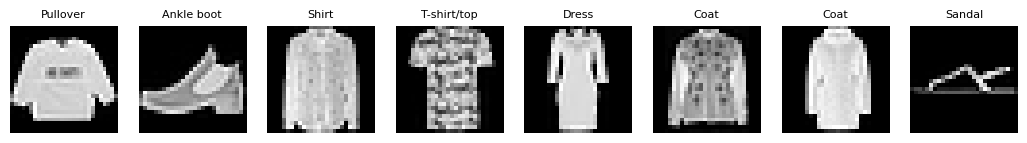

In [9]:
# quick look at what the classes actualy are
fig, ax = plt.subplots(1, 8, figsize=(13, 2))
for i in range(8):
    ax[i].imshow(Xtr[i, 0], cmap='gray')
    ax[i].set_title(class_names[ytr[i]], fontsize=8)
    ax[i].axis('off')
plt.show()

## tensors and batches

60k images is too many to push through at once, so i wrap it in a DataLoader and train in mini batches of 128.

In [10]:
Xtr_t = torch.tensor(Xtr, dtype=torch.float32)
ytr_t = torch.tensor(ytr, dtype=torch.long)
Xte_t = torch.tensor(Xte, dtype=torch.float32)
yte_t = torch.tensor(yte, dtype=torch.long)

train_loader = DataLoader(TensorDataset(Xtr_t, ytr_t), batch_size=128, shuffle=True)
print('batches per epoch:', len(train_loader))

batches per epoch: 469


## the CNN

two conv blocks (conv, relu, pool) to pull out features, then flatten into a dense head for the 10 classes. built with Sequential so its just a stack.

In [11]:
cnn = nn.Sequential(
    nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 28 -> 14
    nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 14 -> 7
    nn.Flatten(),
    nn.Linear(32 * 7 * 7, 128), nn.ReLU(),
    nn.Linear(128, 10)
)
print(cnn)

Sequential(
  (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Flatten(start_dim=1, end_dim=-1)
  (7): Linear(in_features=1568, out_features=128, bias=True)
  (8): ReLU()
  (9): Linear(in_features=128, out_features=10, bias=True)
)


## train

adam + cross entropy, a few epochs over the batches. i keep the average loss each epoch.

In [ ]:
opt = torch.optim.Adam(cnn.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

history = []
for epoch in range(20):
    cnn.train()
    running = 0.0
    for xb, yb in train_loader:
        opt.zero_grad()
        loss = loss_fn(cnn(xb), yb)
        loss.backward()
        opt.step()
        running += loss.item()
    avg = running / len(train_loader)
    history.append(avg)
    print(f'epoch {epoch+1}  loss {avg:.4f}')

epoch 1  loss 0.5968
epoch 2  loss 0.3532
epoch 3  loss 0.3036
epoch 4  loss 0.2723
epoch 5  loss 0.2532
epoch 6  loss 0.2346
epoch 7  loss 0.2196
epoch 8  loss 0.2058
epoch 9  loss 0.1960
epoch 10  loss 0.1832
epoch 11  loss 0.1727
epoch 12  loss 0.1624
epoch 13  loss 0.1524
epoch 14  loss 0.1425
epoch 15  loss 0.1353
epoch 16  loss 0.1255
epoch 17  loss 0.1174
epoch 18  loss 0.1074
epoch 19  loss 0.1024
epoch 20  loss 0.0931


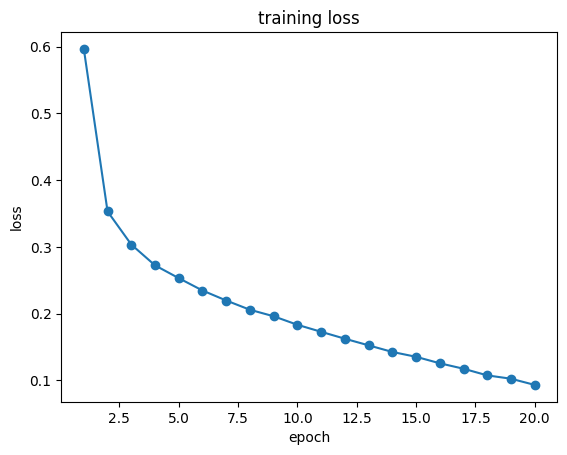

In [13]:
plt.plot(range(1, len(history) + 1), history, marker='o')
plt.xlabel('epoch'); plt.ylabel('loss')
plt.title('training loss')
plt.show()

In [14]:
cnn.eval()
with torch.no_grad():
    preds = cnn(Xte_t).argmax(1)
acc = (preds == yte_t).float().mean().item()
print('test accuracy', round(acc, 4))

test accuracy 0.9216


## actual vs predicted

green title means it got it right, red means wrong (with the true label in brackets).

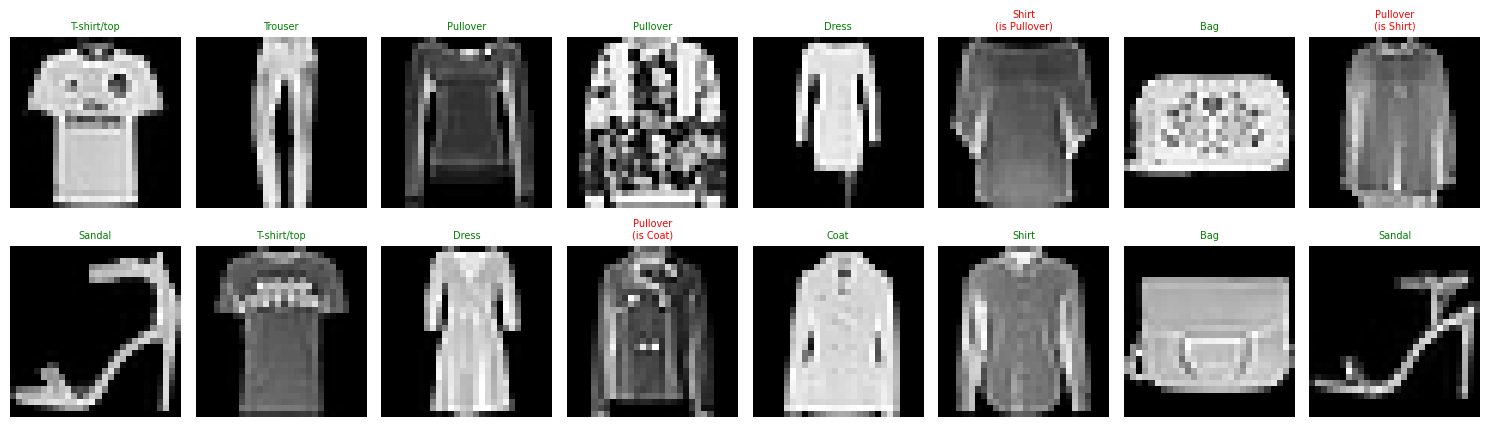

In [15]:
fig, ax = plt.subplots(2, 8, figsize=(15, 4.5))
for k in range(16):
    i = k
    a = ax[k // 8][k % 8]
    a.imshow(Xte[i, 0], cmap='gray')
    p, t = preds[i].item(), yte[i]
    ok = p == t
    title = class_names[p] if ok else f'{class_names[p]}\n(is {class_names[t]})'
    a.set_title(title, color='green' if ok else 'red', fontsize=7)
    a.axis('off')
plt.tight_layout()
plt.show()

In [16]:
# which classes does it mix up the most
wrong = (preds != yte_t)
print('misclassified', int(wrong.sum().item()), 'of', len(yte))
for cls in range(10):
    mask = (yte_t == cls)
    cls_acc = (preds[mask] == yte_t[mask]).float().mean().item()
    print(f'  {class_names[cls]:12s} {cls_acc:.3f}')

misclassified 784 of 10000
  T-shirt/top  0.889
  Trouser      0.992
  Pullover     0.871
  Dress        0.871
  Coat         0.892
  Sandal       0.987
  Shirt        0.817
  Sneaker      0.933
  Bag          0.988
  Ankle boot   0.976


### quick recap

same kind of CNN as the digits one but on harder data and built straight from pytorch instead of numpy. it gets into the low 90s on the test set, and the per class accuracy shows shirts and pullovers (and t-shirts) are the ones it confuses, wich makes sense becuase they look alot alike in 28x28 grayscale.